Saved: /Users/chenweihu/Documents/PSI/Green Data/ETS/UP_state_profile_geoplot.png


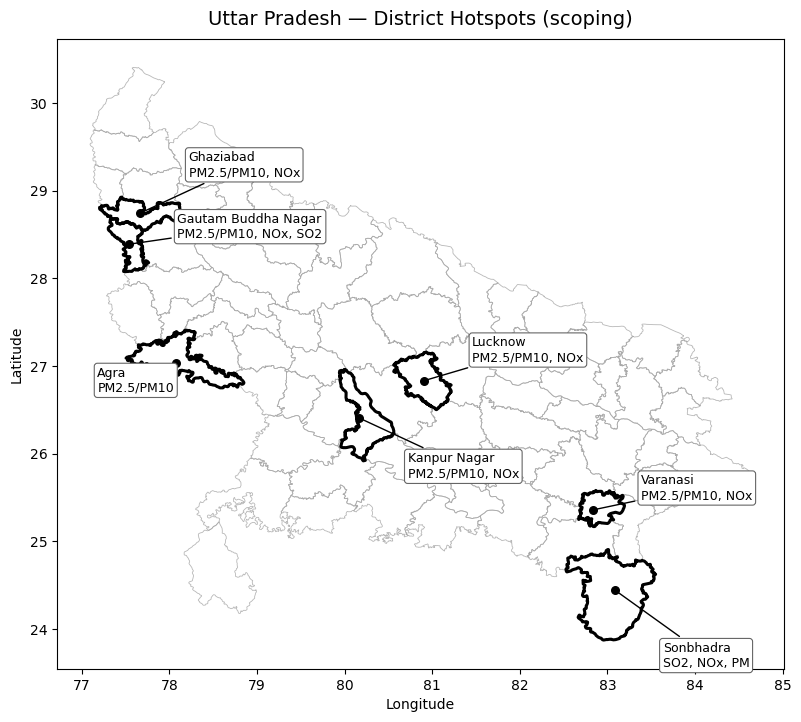

In [ ]:
import os, json, zipfile
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 1) Paths
ZIP_PATH = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps-master.zip"
EXTRACT_DIR = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps_master_extracted"
GEOJSON_IN_ZIP = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps-master/docs/data/geojson/dists11.geojson"
GEOJSON_FALLBACK = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps-master/website/docs/data/geojson/dists11.geojson"
OUT_PATH = "/Users/chenweihu/Documents/PSI/Green Data/ETS/UP_state_profile_geoplot.png"

os.makedirs(EXTRACT_DIR, exist_ok=True)

# 2) Extract GeoJSON
#with zipfile.ZipFile(ZIP_PATH, "r") as z:
#    names = set(z.namelist())
#    if GEOJSON_IN_ZIP in names:
#        geojson_member = GEOJSON_IN_ZIP
#    elif GEOJSON_FALLBACK in names:
#        geojson_member = GEOJSON_FALLBACK
#    else:
#        raise FileNotFoundError("Could not find dists11.geojson inside the zip.")
#
#    z.extract(geojson_member, path=EXTRACT_DIR)

GEOJSON_PATH = os.path.join(EXTRACT_DIR, GEOJSON_IN_ZIP)

# 3) Load + filter UP
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    gj = json.load(f)

# Expected properties in this dataset: DISTRICT, ST_NM, etc.
feats_up = [
    ft for ft in gj["features"]
    if str(ft["properties"].get("ST_NM", "")).strip().lower() == "uttar pradesh"
]

# 4) Helpers: iterate rings + centroid
def iter_rings(geom):
    gtype = geom["type"]
    coords = geom["coordinates"]
    if gtype == "Polygon":
        for ring in coords:
            yield ring
    elif gtype == "MultiPolygon":
        for poly in coords:
            for ring in poly:
                yield ring

def rough_centroid(geom):
    xs = ys = n = 0
    for ring in iter_rings(geom):
        for x, y in ring:
            xs += x; ys += y; n += 1
    return (xs / n, ys / n) if n else (None, None)

# 5) Hotspots + labels
hotspots = {
    "Ghaziabad": "PM2.5/PM10, NOx",
    "Gautam Buddha Nagar": "PM2.5/PM10, NOx, SO2",
    "Agra": "PM2.5/PM10",
    "Kanpur Nagar": "PM2.5/PM10, NOx",
    "Lucknow": "PM2.5/PM10, NOx",
    "Varanasi": "PM2.5/PM10, NOx",
    "Sonbhadra": "SO2, NOx, PM",
}

# Manual label offsets (lon, lat) to avoid overlap (tweak if needed)
offsets = {
    "Ghaziabad": (0.55, 0.55),
    "Gautam Buddha Nagar": (0.55, 0.20),
    "Agra": (-0.90, -0.20),
    "Kanpur Nagar": (0.55, -0.55),
    "Lucknow": (0.55, 0.35),
    "Varanasi": (0.55, 0.25),
    "Sonbhadra": (0.55, -0.75),
}

# Collect hotspot features + centroids
hot_feats = []
hot_centroids = {}
for ft in feats_up:
    dname = str(ft["properties"].get("DISTRICT", "")).strip()
    if dname in hotspots:
        hot_feats.append(ft)
        cx, cy = rough_centroid(ft["geometry"])
        if cx is not None:
            hot_centroids[dname] = (cx, cy)

# 6) Plot
fig = plt.figure(figsize=(13.5, 7.5))
ax = fig.add_axes([0.05, 0.08, 0.68, 0.84])  # map

# Base UP districts (light gray)
for ft in feats_up:
    geom = ft["geometry"]
    for ring in iter_rings(geom):
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.plot(xs, ys, lw=0.6, color="0.65", alpha=0.8)

# Highlight hotspots (thicker black)
for ft in hot_feats:
    geom = ft["geometry"]
    for ring in iter_rings(geom):
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.plot(xs, ys, lw=2.2, color="black")

# Labels
for dname, (cx, cy) in hot_centroids.items():
    dx, dy = offsets.get(dname, (0.5, 0.5))
    ax.scatter([cx], [cy], s=30, color="black", zorder=5)
    ax.annotate(
        f"{dname}\n{hotspots[dname]}",
        xy=(cx, cy),
        xytext=(cx + dx, cy + dy),
        fontsize=9,
        va="center",
        arrowprops=dict(arrowstyle="-", lw=1, color="black"),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.4", lw=0.8),
        zorder=6,
    )

ax.set_title("Uttar Pradesh — District Hotspots (scoping)", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")

# Save for slides
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print("Saved:", OUT_PATH)


In [ ]:
import os, json
import matplotlib.pyplot as plt

# Input (already extracted; no ZIP)
EXTRACT_DIR = "/mnt/data/maps_master_extracted"
GEOJSON_PATH = os.path.join(EXTRACT_DIR, "maps-master/docs/data/geojson/dists11.geojson")
OUT_PATH = "/mnt/data/UP_district_boundaries_highlighted.png"

# Region groups to highlight
# (edit district names here if your GeoJSON uses slightly different spellings)
REGIONS = {
    "NCR (Ghaziabad/Noida)": {
        "districts": ["Ghaziabad", "Gautam Buddha Nagar"],
        "color": "#1F4E79",  # navy
    },
    "Kanpur Nagar, Unnao": {
        "districts": ["Kanpur Nagar", "Unnao"],
        "color": "#B63A2B",  # red
    },
    "Agra": {
        "districts": ["Agra"],
        "color": "#F39C34",  # orange
    },
    "Varanasi, Mirzapur": {
        "districts": ["Varanasi", "Mirzapur"],
        "color": "#5DADE2",  # light blue
    },
    # Optional: if you want Mirzapur/Varanasi belt larger, add "Chandauli", "Jaunpur", etc.
}

BASE_FILL = "white"
BASE_EDGE = "0.55"
BASE_LW = 0.6
HILITE_EDGE = "white"
HILITE_LW = 1.2

# Load + filter UP
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    gj = json.load(f)

feats_up = [
    ft for ft in gj["features"]
    if str(ft["properties"].get("ST_NM", "")).strip().lower() == "uttar pradesh"
]

def iter_rings(geom):
    gtype = geom["type"]
    coords = geom["coordinates"]
    if gtype == "Polygon":
        for ring in coords:
            yield ring
    elif gtype == "MultiPolygon":
        for poly in coords:
            for ring in poly:
                yield ring

# Build district -> feature
dist_to_feat = {}
for ft in feats_up:
    dname = str(ft["properties"].get("DISTRICT", "")).strip()
    dist_to_feat[dname] = ft

# Bounds for tight crop
all_x, all_y = [], []
for ft in feats_up:
    for ring in iter_rings(ft["geometry"]):
        for x, y in ring:
            all_x.append(x); all_y.append(y)
minx, maxx = min(all_x), max(all_x)
miny, maxy = min(all_y), max(all_y)
padx = (maxx - minx) * 0.03
pady = (maxy - miny) * 0.03

# Plot: boundaries + highlighted regions
fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()

# Base: all UP districts in white with gray outlines
for ft in feats_up:
    for ring in iter_rings(ft["geometry"]):
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.fill(xs, ys, facecolor=BASE_FILL, edgecolor=BASE_EDGE, linewidth=BASE_LW, zorder=1)

# Overlay: highlight selected districts
missing = []
for region_name, meta in REGIONS.items():
    for d in meta["districts"]:
        ft = dist_to_feat.get(d)
        if ft is None:
            missing.append(d)
            continue
        for ring in iter_rings(ft["geometry"]):
            xs = [p[0] for p in ring]
            ys = [p[1] for p in ring]
            ax.fill(xs, ys, facecolor=meta["color"], edgecolor=HILITE_EDGE, linewidth=HILITE_LW, zorder=3)

# Tight crop
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

# Save (transparent background is useful for slides)
fig.savefig(OUT_PATH, dpi=400, bbox_inches="tight", pad_inches=0.0, transparent=True)
print("Saved:", OUT_PATH)

if missing:
    print("Warning: these districts were not found in the GeoJSON DISTRICT field:", sorted(set(missing)))

plt.show()


Saved: /Users/chenweihu/Documents/PSI/Green Data/ETS/UP_state_profile_geoplot.png


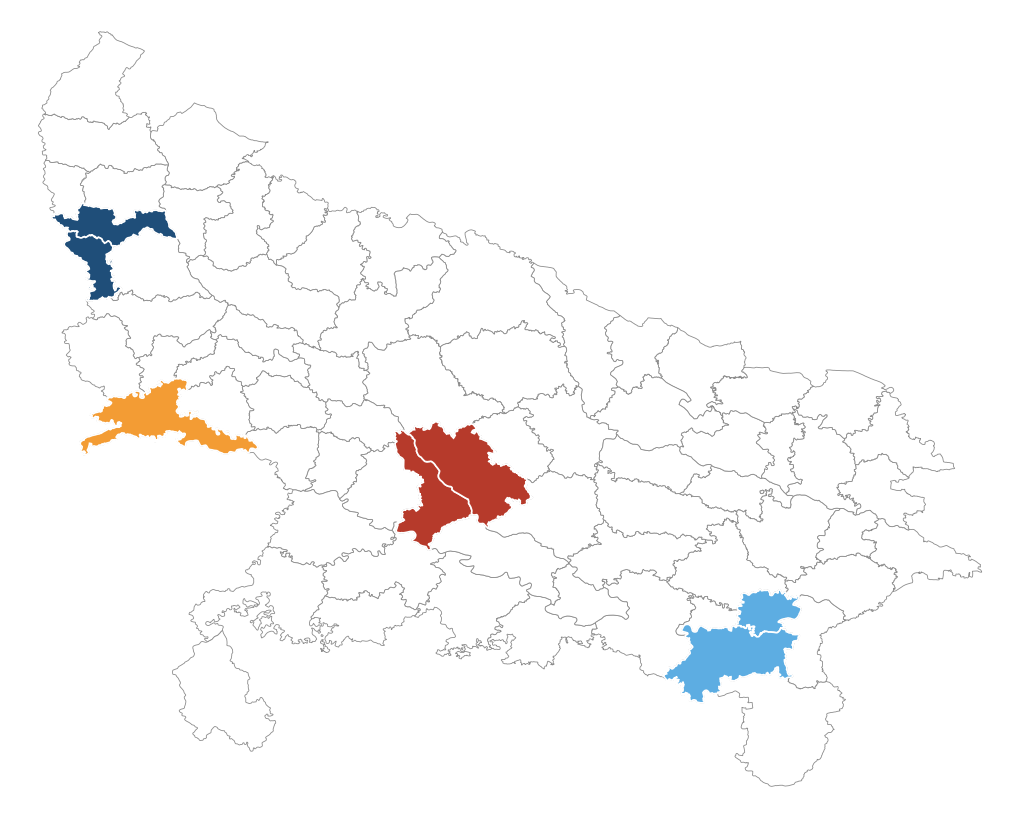

In [13]:
import os, json
import matplotlib.pyplot as plt

# Input (already extracted; no ZIP)
EXTRACT_DIR = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps_master_extracted"
GEOJSON_PATH = "/Users/chenweihu/Documents/PSI/Green Data/ETS/maps-master/docs/data/geojson/dists11.geojson"
OUT_PATH = "/Users/chenweihu/Documents/PSI/Green Data/ETS/UP_state_profile_geoplot.png"

# Region groups to highlight
# (edit district names here if your GeoJSON uses slightly different spellings)
REGIONS = {
    "NCR (Ghaziabad/Noida)": {
        "districts": ["Ghaziabad", "Gautam Buddha Nagar"],
        "color": "#1F4E79",  # navy
    },
    "Kanpur Nagar, Unnao": {
        "districts": ["Kanpur Nagar", "Unnao"],
        "color": "#B63A2B",  # red
    },
    "Agra": {
        "districts": ["Agra"],
        "color": "#F39C34",  # orange
    },
    "Varanasi, Mirzapur": {
        "districts": ["Varanasi", "Mirzapur"],
        "color": "#5DADE2",  # light blue
    },
    # Optional: if you want Mirzapur/Varanasi belt larger, add "Chandauli", "Jaunpur", etc.
}

BASE_FILL = "white"
BASE_EDGE = "0.55"
BASE_LW = 0.6
HILITE_EDGE = "white"
HILITE_LW = 1.2

# Load + filter UP
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    gj = json.load(f)

feats_up = [
    ft for ft in gj["features"]
    if str(ft["properties"].get("ST_NM", "")).strip().lower() == "uttar pradesh"
]

def iter_rings(geom):
    gtype = geom["type"]
    coords = geom["coordinates"]
    if gtype == "Polygon":
        for ring in coords:
            yield ring
    elif gtype == "MultiPolygon":
        for poly in coords:
            for ring in poly:
                yield ring

# Build district -> feature
dist_to_feat = {}
for ft in feats_up:
    dname = str(ft["properties"].get("DISTRICT", "")).strip()
    dist_to_feat[dname] = ft

# Bounds for tight crop
all_x, all_y = [], []
for ft in feats_up:
    for ring in iter_rings(ft["geometry"]):
        for x, y in ring:
            all_x.append(x); all_y.append(y)
minx, maxx = min(all_x), max(all_x)
miny, maxy = min(all_y), max(all_y)
padx = (maxx - minx) * 0.03
pady = (maxy - miny) * 0.03

# Plot: boundaries + highlighted regions
fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()

# Base: all UP districts in white with gray outlines
for ft in feats_up:
    for ring in iter_rings(ft["geometry"]):
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.fill(xs, ys, facecolor=BASE_FILL, edgecolor=BASE_EDGE, linewidth=BASE_LW, zorder=1)

# Overlay: highlight selected districts
missing = []
for region_name, meta in REGIONS.items():
    for d in meta["districts"]:
        ft = dist_to_feat.get(d)
        if ft is None:
            missing.append(d)
            continue
        for ring in iter_rings(ft["geometry"]):
            xs = [p[0] for p in ring]
            ys = [p[1] for p in ring]
            ax.fill(xs, ys, facecolor=meta["color"], edgecolor=HILITE_EDGE, linewidth=HILITE_LW, zorder=3)

# Tight crop
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

# Save (transparent background is useful for slides)
fig.savefig(OUT_PATH, dpi=400, bbox_inches="tight", pad_inches=0.0, transparent=True)
print("Saved:", OUT_PATH)

if missing:
    print("Warning: these districts were not found in the GeoJSON DISTRICT field:", sorted(set(missing)))

plt.show()
